In [110]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.applications.vgg16 import VGG16
from keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt
EarlyStopping = tf.keras.callbacks.EarlyStopping

In [111]:
import os

if not os.path.exists("/root/.kaggle"):
  os.makedirs("/root/.kaggle")

!mv kaggle.json /root/.kaggle
!chmod 600 /root/.kaggle/kaggle.json

mv: cannot stat 'kaggle.json': No such file or directory


In [112]:
!kaggle datasets download -d samuelcortinhas/cats-and-dogs-image-classification
!unzip -qq cats-and-dogs-image-classification.zip

Dataset URL: https://www.kaggle.com/datasets/samuelcortinhas/cats-and-dogs-image-classification
License(s): CC0-1.0
cats-and-dogs-image-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
replace test/cats/cat_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [113]:
conv_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(256,256,3)
)

In [114]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [115]:
from keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [116]:
from keras.layers import GlobalAveragePooling2D

model = Sequential([
    data_augmentation,
    conv_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [117]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [118]:
conv_base.trainable = False

In [119]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_8 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [120]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "/content/train",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(256,256),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "/content/train",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(256,256),
    batch_size=32
)

test = tf.keras.utils.image_dataset_from_directory(
    "/content/test",
    seed=123,
    image_size=(256,256),
    batch_size=32
)

Found 557 files belonging to 2 classes.
Using 446 files for training.
Found 557 files belonging to 2 classes.
Using 111 files for validation.
Found 140 files belonging to 2 classes.


In [121]:
from keras.applications.vgg16 import preprocess_input

def normalize(img, label):
    img = preprocess_input(img)
    return img, label

train_data = train_data.map(normalize)
val_data = val_data.map(normalize)
test = test.map(normalize)

In [122]:
callbacks = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
)

In [123]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [124]:
history = model.fit(
    train_data,
    epochs=10,
    callbacks=callbacks,
    validation_data=test
)

Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 737ms/step - accuracy: 0.5759 - loss: 1.2239 - val_accuracy: 0.8714 - val_loss: 0.4592
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - accuracy: 0.7994 - loss: 0.5830 - val_accuracy: 0.9357 - val_loss: 0.2278
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 274ms/step - accuracy: 0.7789 - loss: 0.5979 - val_accuracy: 0.9071 - val_loss: 0.2517
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 324ms/step - accuracy: 0.8889 - loss: 0.2381 - val_accuracy: 0.9500 - val_loss: 0.1492
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 296ms/step - accuracy: 0.9088 - loss: 0.2397 - val_accuracy: 0.9357 - val_loss: 0.1637
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 279ms/step - accuracy: 0.9163 - loss: 0.1939 - val_accuracy: 0.9500 - val_loss: 0.1886
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 319ms/step - accuracy: 0.8991 - loss: 0.2068 - val_accuracy: 0.9571 - val_loss: 0.1691
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step - accuracy: 0.8978 - loss: 0.2459 - val_accuracy: 0

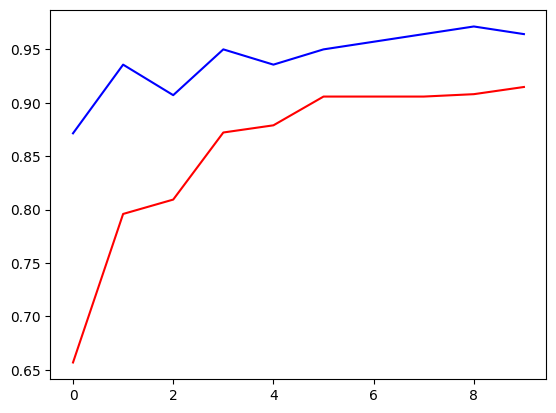

In [125]:
from matplotlib import pyplot as plt
plt.plot(history.history['accuracy'], c='r')
plt.plot(history.history['val_accuracy'], c='b')
plt.show()

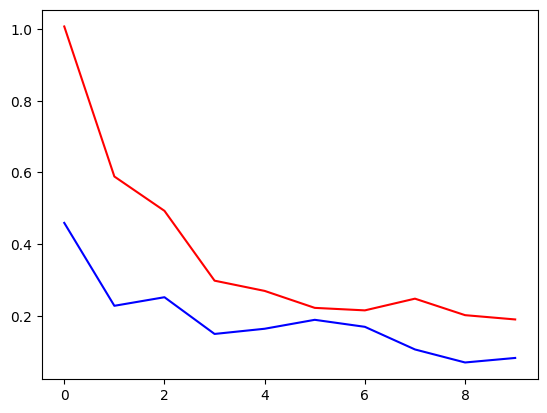

In [126]:
from matplotlib import pyplot as plt
plt.plot(history.history['loss'], c='r')
plt.plot(history.history['val_loss'], c='b')
plt.show()

In [127]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test:
    preds = model.predict(images, verbose=0)
    preds = (preds > 0.5).astype(int)   # threshold = 0.5

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [128]:
test_loss, test_acc = model.evaluate(test)

print(f"Test Accuracy : {test_acc:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.9794 - loss: 0.0532
Test Accuracy : 0.9643
